In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from sklearn.preprocessing import normalize

## Load ResNet50 Feature Embeddings

In [2]:
train_df = pd.read_csv(
    "../Outputs/Notebook_03/train_embeddings.csv"
)

print("Original Shape :", train_df.shape)

Original Shape : (14446, 513)


## Keep Only Left Iris Images

In [3]:
train_df = train_df[
    train_df["Image"].str.contains("L")
].reset_index(drop=True)

print("Left Eye Dataset Shape :", train_df.shape)

Left Eye Dataset Shape : (7172, 513)


In [4]:
image_names = train_df["Image"].copy()

train_features = train_df.drop(
    columns=["Image"]
)

print(train_features.shape)

(7172, 512)


## Apply Principal Component Analysis (PCA)

In [5]:
pca = PCA(
    n_components=128,
    random_state=42
)

compressed_embeddings = pca.fit_transform(
    train_features
)

print(
    "Compressed Shape :",
    compressed_embeddings.shape
)

Compressed Shape : (7172, 128)


## Normalize Compressed Feature Vectors

In [6]:
normalized_features = normalize(
    compressed_embeddings,
    norm="l2"
)

print(
    normalized_features.shape
)

(7172, 128)


## Analyze PCA Variance Retention

In [7]:
variance_retained = np.sum(
    pca.explained_variance_ratio_
)

print(
    "Variance Retained :",
    round(
        variance_retained * 100,
        2
    ),
    "%"
)

Variance Retained : 92.08 %


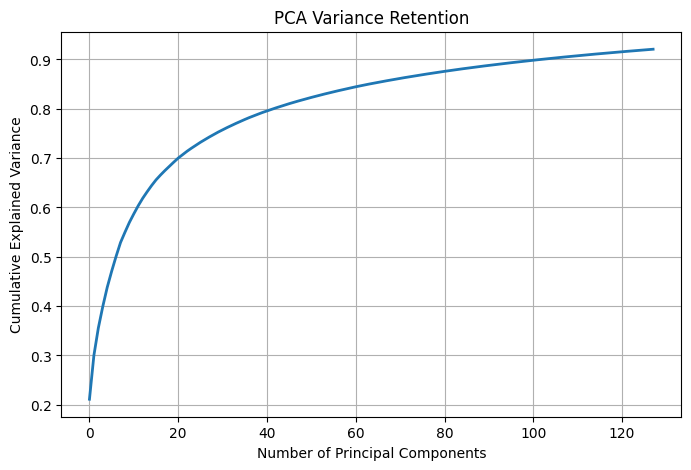

In [8]:
plt.figure(figsize=(8,5))

plt.plot(
    np.cumsum(
        pca.explained_variance_ratio_
    ),
    linewidth=2
)

plt.xlabel(
    "Number of Principal Components"
)

plt.ylabel(
    "Cumulative Explained Variance"
)

plt.title(
    "PCA Variance Retention"
)

plt.grid(True)

os.makedirs(
    "../Outputs/Notebook_05",
    exist_ok=True
)

plt.savefig(
    "../Outputs/Notebook_05/pca_variance_retention.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Save PCA Compressed Embeddings

In [9]:
compressed_df = pd.DataFrame(
    compressed_embeddings
)

compressed_df.to_csv(
    "../Outputs/Notebook_05/compressed_embeddings.csv",
    index=False
)

print(
    "Compressed Embeddings Saved"
)

print(
    compressed_df.shape
)

Compressed Embeddings Saved
(7172, 128)


## Save Normalized Feature Embeddings

In [10]:
normalized_df = pd.DataFrame(
    normalized_features
)

normalized_df.to_csv(
    "../Outputs/Notebook_05/normalized_features.csv",
    index=False
)

print(
    "Normalized Embeddings Saved"
)

print(
    normalized_df.shape
)

Normalized Embeddings Saved
(7172, 128)


## Save Compressed Embeddings with Image Names

In [11]:
compressed_with_image = compressed_df.copy()

compressed_with_image.insert(
    0,
    "Image",
    image_names
)

compressed_with_image.to_csv(
    "../Outputs/Notebook_05/compressed_embeddings_with_image.csv",
    index=False
)

print(
    "Compressed Embeddings with Image Names Saved"
)

print(
    compressed_with_image.shape
)

Compressed Embeddings with Image Names Saved
(7172, 129)


## Save Normalized Embeddings with Image Names

In [12]:
normalized_with_image = normalized_df.copy()

normalized_with_image.insert(
    0,
    "Image",
    image_names
)

normalized_with_image.to_csv(
    "../Outputs/Notebook_05/normalized_features_with_image.csv",
    index=False
)

print(
    "Normalized Embeddings with Image Names Saved"
)

print(
    normalized_with_image.shape
)

Normalized Embeddings with Image Names Saved
(7172, 129)
